<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../../Index.ipynb" target="_blank"><< Index</a>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2025 European Union <br>
**License:** MIT <br>
**Authors:** Ben Loveday (EUMETSAT/Innoflair UG), Hayley Evers-King (EUMETSAT), Juan Ignacio-Gossn (EUMETSAT)

<html>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-colour-applications"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://user.eumetsat.int/data/themes/marine"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://code.insula.destine.eu/hub/"><img src="https://img.shields.io/badge/launch-DestinE-f43fd3.svg"></a></div></div>
</html>

<div class="alert alert-block alert-success">
<h3>Ocean colour applications</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
This notebook has the following prerequisites:
- **<a href="https://user.eumetsat.int/cas/login" target="_blank">A EUMETSAT User Portal account</a>** to enable you to download products from the EUMETSAT Data Store.

There are no prerequisite notebooks for this module, but you may be interested in the following GitLab repositories if you wish to learn more about using marine data from Sentinel-3 OLCI, or the ThoMaS Match-up validation toolkit:
- **<a href="https://gitlab.eumetsat.int/eo-lab-usc-open/ocean/sensors/learn-olci" target="_blank">learn-olci</a>**
- **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS" target="_blank">ThoMaS</a>**


WHERE TO RUN THIS NOTEBOOK?

This notebook can be run on a local machine or on a remote cloud system, and is tested on WEkEO and the DestinE Insula Code services. You can use the buttons at the top of the notebook to access these platforms, but you will need a free account on whichever service you choose. Full instructions for how to set up this notebook is provided in the README. Running on Binder is not possible due to the size of dependencies.
</div>
<hr>

# Validating ocean colour products with cruise track data using the ThoMaS toolkit
<font color="#138D75">**Devloped by EUMETSAT in support of the 2025 ESA OTC course**</font>


### Data used

| Dataset | EUMETSAT collection ID| EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Sentinel-3 OLCI level 2 full resolution | EO:EUM:DAT:0407 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_2_WFR___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:OL_2_WFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_2_WFR___" target="_blank">Description</a> |
| Sentinel-3 OLCI level 2 full resolution BC003 reprocessing | EO:EUM:DAT:0556 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0556" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:0556 | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3A0556" target="_blank">Description</a> |

### Learning outcomes

At the end of this notebook you will know;
* how to use the ThoMaS toolkit to perform OLCI match-up validation extractions and analyses against chlorophyll-a concentration data collected along a cruise track.

### Outline

Validation studies are essential to ensuring satellite sensor performance and a necessary part of algorithm development. The ThoMaS (Tool to generate Matchups of OC products with Sentinel-3/OLCI) package provides a comprehensive set of tools to help with the validation of OLCI products (as well as products from other satellites), supporting many common workflow elements including;
* satellite data acquisition
* mini file extraction
* *in situ* data management
* BRDF correction
* Statistical analysis comparing in situ and satellite data 

ThoMaS provides a tool that incorporates protocols, that have been developed over many years via multiple satellite operations agencies, and interactions with the community. It works with inputs from standard databases (e.g. SeaBASS, and OCDB) and offers various configuration options, allowing users to compute comparable matchup analyses, but also have some flexibility for their own applications. 

ThoMaS is written in Python and is made available through a **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS" target="_blank">EUMETSAT Gitlab repository</a>**. The package can be used from the command line,  via a GUI, or imported as a Python library, as done here. This notebook contains 1 example of how to use ThoMaS. Further examples can be found in other notebooks e.g. on **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-olci/-/blob/main/2_OLCI_advanced/2_4_OLCI_matchup_validation.ipynb?ref_type=heads" target="_blank">OLCI Matchup validation</a>** and **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-olci/-/blob/main/2_OLCI_advanced/2_5_multisensor_matchup_validation.ipynb?ref_type=heads" target="_blank">Multisensor matchup validation</a>**. Many more command-line examples are included in the ThoMaS repository itself.

We encourage users to familiarise themselves with both the **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README.md" target="_blank">project README</a>** and **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md" target="_blank"> example README</a>** for more information


Before we begin you should note that this notebook can be run locally, or on a remote cloud system, by cloning the **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-colour-applications" target="_blank">ocean-colour-applications</a>** repository. The **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-colour-applications/-/blob/main/README.md" target="_blank">README</a>** file will fully describe how to create an appropriate Python environment to run this code.

**Note: to download the required EUMETSAT OLCI data, you will need to register for a <a href="https://user.eumetsat.int/cas/login" target="_blank">EUMETSAT User Portal</a> account. Please see the prerequisites for more information on how to do this**.

ThoMaS is in continuous development, with more updates coming soon with advanced workflows including and propogating uncertainties, an updated GUI and serverless function integration with WEkEO to reduce data downloads and local processing needs.

ThoMaS is a tool to support our user community so we would love your feedback, ideas, and contributions to its development. Please contact the
<a href=mailto:ops@eumetsat.int target="_blank">EUMETSAT helpdesk</a>.

<div class="alert alert-info" role="alert">

## <a id='TOC-TOP'></a>Contents

</div>

1. [Step 1: Setting up our analysis](#section1)
1. [------: A quick preamble on functions](#section0)
1. [Step 2: Loading and plotting our cruise tracks](#section2)
1. [Step 3: Loading ThoMaS](#section3)
1. [Step 4: Configuring ThoMaS](#section4)
2. [What next?](#section6)

<hr>

<div class="alert alert-info" role="alert">

## <a id='section1'></a>Step 1: Setting up our analysis
[Back to top](#TOC_TOP)

</div>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python using the environment file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-colour-applications/-/blob/main/README.md" target="_blank">README</a>**.

In [1]:
import os                                   # a library that allows us access to basic operating system commands like making directories
import sys                                  # a library that provides access to system commands
import pandas as pd                         # a library that helps us manipulate data 
import shutil                               # a library that allows us access to basic operating system commands like copy
import numpy as np                          # a library that provides support for array-based mathematics
from IPython.display import Image, display  # a library that helps us plot images
import glob                                 # a library that helps us find files
import datetime                             # a library that helps us handle dates
import matplotlib.pyplot as plt             # a libray that helps us make plots
import cartopy                              # a library that helps us map data
import xarray as xr                         # a library that helps us work efficiently with multi-dimensional arrays

For our analysis, we will need the ThoMaS toolkit. The first thing we need to do is retrieve the tool kit itself. We can do this using the external `! git clone` command. This will create a directory called **ThoMaS** in this path and make the code available for import. If the directory already exists, this cell will be skipped.

In [2]:
if os.path.exists(os.path.join("ThoMaS", "main.py")):
    print("ThoMaS is already installed.")
else:
    ! git clone --depth 1 https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS.git

Cloning into 'ThoMaS'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 262 (delta 110), reused 123 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (262/262), 14.08 MiB | 4.91 MiB/s, done.
Resolving deltas: 100% (110/110), done.


Lets set a couple of quick parameters that help us with handling data. `pad` will set a buffer around our cruise data for plotting. `cruise_point_min`, `cruise_point_max` will subsample our cruise data as required, and `max_depth` will allows us to filter our data for shallow measurements.

In [3]:
pad = 1
cruise_point_min = 0
cruise_point_max = -1
max_depth = 15

<div class="alert alert-warning" role="alert">

## <a id='section0'></a>A quick preamble on functions
[Back to top](#TOC_TOP)

</div>

Before we go any further we are going to define a couple of quick functions. The first helps us to write our configuration options to a file.

*Note: We don't need to write our configurations in python, we could always just write the configuration file directly and point ThoMaS to it*

In [4]:
# Write config_params sections into config_file.ini
def write_config_file(path_to_config_file,config_params):
    with open(path_to_config_file, 'w') as text_file:
        for section,section_params in config_params.items():
            text_file.write('\n[%s]\n' % (section))
            for param, value in section_params.items():
                text_file.write('%s: %s\n' % (param, value))

The second function simply just adds embellishments (gridlines, labels etc) to plots.

In [5]:
def embellish_plot(m):
    """Quick function to embellish SLSTR plots with gridlines and labels

    Args:
        m (axis): the axis to plot into
    Returns:
        None
    """
    # add some map embellishments
    m.add_feature(cartopy.feature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='k', facecolor='#546d51', linewidth=0.5), zorder=8)
    g1 = m.gridlines(draw_labels = True, linestyle='--', zorder=10)
    g1.top_labels = g1.right_labels = False
    g1.xlabel_style = g1.ylabel_style = {'color': 'gray'}

<div class="alert alert-info" role="alert">

## <a id='section2'></a>Step 2: Loading and plotting our cruise track
[Back to top](#TOC_TOP)

</div>

<figure>
  <img src='../../img/Cruise_track.png' align='right' width='55%'/>
</figure>

Lets start by taking a look at the proposed cruise track for the Statsraad Lehmkuhl for the ESA OTC 2025 course, as shown on the right. Here, the markers show us the way points logged for the cruise, and not all the actual sampling positions. Of course, as this cruise is ongoing we don't yet have any data to compare with any chlorophyll-a products, so we will use another cruise that covers some of the same area as an example.

For our test cruise, we will use the first leg AWI Polerstern expedition <a href="https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2020.00235/full">PS113</a> as it sampled northeastern Atlantic quite recently. The cruise data is also freely available through <a href="https://doi.pangaea.de/10.1594/PANGAEA.911061">Pangaea</a>, and incudes pigment analysis. We will use the chlorophyll-a data from this instrument as the *in situ* data set for our analysis, but you could choose any other cruise to do the same analysis, provided you correctly map the data when you ingest it (more on this below).

Lets read in the data from the cruise track, as stored in our "tracks" directory, using the `pandas` package (which we imported under the alias "pd"). Our specific cruise data is stored in the "PS113_HPLC_pigments_PFTs_QCle30.tab" file, which includes an 83-line header description followed by a series of tab-separated columns containing our data. We need to specify the number of header rows to skip them when reading the file, as well as the delimiter (in this case tab, or '\t'). 

We will also subsample the output in time using our `cruise_subsample` parameter we set above.

In [6]:
df = pd.read_csv(os.path.join(os.getcwd(), "tracks", "PS113_HPLC_pigments_PFTs_QCle30.tab"), header=83, delimiter='\t')
df = df[cruise_point_min:cruise_point_max]
df = df[df["Depth water [m]"] < 15]

Lets check our data out...

In [7]:
df

,Event,Station,Gear,Date/Time,Latitude,Longitude,Depth water [m],Sample ID,Province (Longhurst Province),Chl c3 [µg/l],...,Pyrophytin a [µg/l],Chl a [µg/l] (Total),Chl a [µg/l] (Haptophytes),Chl a [µg/l] (Diatoms),Chl a [µg/l] (Dinoflagellates),Chl a [µg/l] (Cyano_noProchl),Chl a [µg/l] (Chlorophytes),Chl a [µg/l] (Cryptophytes),Chl a [µg/l] (Chrysophytes),Chl a [µg/l] (Prochl)
0,PS113_1-2,PS113_1-2,CTD/Rosette,2018-05-10T18:37,-47.64596,-60.71218,11,3,SWAS,0.125,...,0.0,1.081,0.288,0.169,0.180,0.047,0.188,0.160,0.049,0.0
6,PS113-track,PS113_UW_1,Underway,2018-05-10T20:02,-47.46346,-60.41880,11,9,SWAS,0.175,...,0.0,0.994,0.322,0.156,0.070,0.061,0.173,0.172,0.041,0.0
7,PS113-track,PS113_UW_2,Underway,2018-05-10T23:01,-47.01404,-59.75913,11,10,SWAS,0.131,...,0.0,0.651,0.421,0.012,0.021,0.020,0.072,0.060,0.044,0.0
8,PS113-track,PS113_UW_3,Underway,2018-05-11T02:04,-46.55360,-59.08934,11,11,SWAS,0.024,...,0.0,0.289,0.136,0.023,0.029,0.009,0.059,0.024,0.008,0.0
9,PS113-track,PS113_UW_4,Underway,2018-05-11T08:01,-45.68854,-57.84590,11,13,BRAZ,0.745,...,0.0,2.653,0.090,2.409,0.000,0.010,0.107,0.017,0.019,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,PS113-track,PS113_UW_195,Underway,2018-06-08T19:58,49.07058,-4.79952,11,342,NECS,0.146,...,0.0,2.249,0.047,1.360,0.288,0.015,0.063,0.473,0.003,0.0
335,PS113-track,PS113_UW_196,Underway,2018-06-08T22:57,49.39310,-3.93282,11,343,NECS,0.103,...,0.0,5.423,0.027,4.686,0.376,0.004,0.067,0.263,0.000,0.0
336,PS113-track,PS113_UW_197,Underway,2018-06-09T01:57,49.72393,-3.03763,11,344,NECS,0.553,...,0.0,4.142,1.449,1.947,0.296,0.013,0.133,0.294,0.009,0.0
337,PS113-track,PS113_UW_198,Underway,2018-06-09T04:59,49.94871,-2.02105,11,345,NECS,0.072,...,0.0,3.399,0.043,2.602,0.388,0.011,0.136,0.219,0.000,0.0


As we can see, we have the spatial and temporal data for the tracks, as well as the "Chl a [µg/l] (total)" data we need to extract for comparison. The time record provided by `pandas` is a little hard to work with, we'll quickly define our own for later use.

In [8]:
cruise_times = [datetime.datetime.strptime(i, "%Y-%m-%dT%H:%M") for i in df["Date/Time"]] 

Lets take a look at our cruise track, plotting the track and the associated underway Chl-a signal.

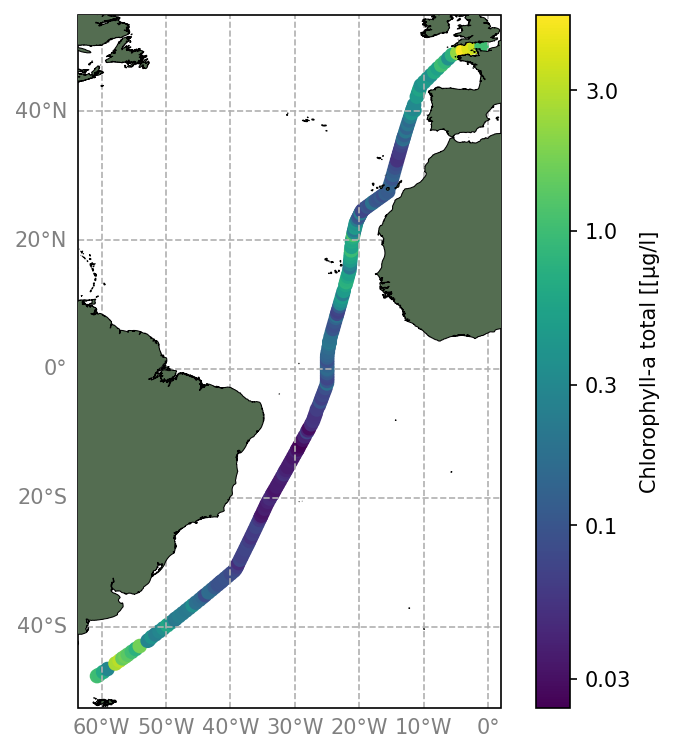

In [9]:
# set up our figure
fig, m = plt.subplots(1, 1, figsize=(6, 6), dpi=150, subplot_kw={"projection": cartopy.crs.PlateCarree()})

# plot cruise track and data points
p2, = m.plot(df["Longitude"], df["Latitude"], zorder=1, color='0.5', transform = cartopy.crs.PlateCarree())
p3 = m.scatter(df["Longitude"], df["Latitude"], c=np.log10(df["Chl a [µg/l]"]), zorder=2, transform = cartopy.crs.PlateCarree(), cmap="viridis", edgecolor=None)

# plot colorbar
cbar = plt.colorbar(p3, label="Chlorophyll-a total [[µg/l]")
tick_labels = [0.03, 0.1, 0.3, 1.0, 3.0]
ticks = [np.log10(i) for i in tick_labels]
cbar.set_ticks(ticks)
cbar.set_ticklabels(tick_labels)

# add some map embellishments
embellish_plot(m)

<div class="alert alert-info" role="alert">

## <a id='section3'></a>Loading ThoMaS
[Back to top](#TOC-TOP)

</div>

Before you use ThoMas, you must ensure that you have have completed the following two steps:
1. Ensure that you have all the Python dependencies you need to run ThoMaS. If you have installed and activated the **cmts_ocean_colour_applications** environment then you are all set.
1. Ensure that ThoMaS can access the EUMETSAT Data Store, which you can do by completing the "**EUMDAC**" section of the <a href="../../working-with-python/API_authentication.ipynb" target="_blank"> set credentials notebook</a>.

ThoMaS can be used from the <a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md" target="_blank">command line</a>, but here we will use it as a Python library. Lets import ThoMaS into our notebook.

In [10]:
sys.path.append("ThoMaS")
from main import ThoMaS_main as ThoMaS

Now we should have ThoMaS imported and configured for use, so we can proceed with our examples.

<div class="alert alert-info" role="alert">

## <a id='section4'></a>Configuring ThoMaS for our experiment
[Back to top](#TOC-TOP)

</div>

<div class="alert alert-success" role="alert">

Run ThoMaS for:

1. our in situ data to SeaBASS/OCDB format
1. full matchup exercise: satellite extractions + minifiles + extraction statistics + matchup statistics
1. apply the <a href="https://ioccg.org/bibliography/morel-a-antoine-d-and-b-gentili-2002/" target="_blank">Morel, Antoine and Gentili, 2002</a> BRDF correction to the reflectances (even though we won't use them here!)
1. apply the <a href="https://user.eumetsat.int/s3/eup-strapi-media/Recommendations_for_Sentinel_3_OLCI_Ocean_Colour_product_validations_in_comparison_with_in_situ_measurements_Matchup_Protocols_V8_B_e6c62ce677.pdf standard extraction protocol" target="_blank">EUMETSAT standard protocol</a> for extractions and for insitu-extraction comparison.


</div>

Firstly, we need to prepare our in situ data in the correct SeaBASS/OCDB format. Lets start by defining our output path and output file.

In [11]:
SetID = 'Cruise'
output_path = os.path.join(os.getcwd(), SetID)
os.makedirs(output_path, exist_ok=True)
path_insitu = os.path.join(output_path, f'{SetID}_OCDB.sb')

Now we will write our data into the correct format, using the OCDB_template.sb template as a start point. We will only consider a subset of the data in this case, to prevent a very long script run-time. `ii_max` sets the maximum number of points to consider.

In [12]:
# make OCDB format output
with open(os.path.join(os.getcwd(), "templates", "OCDB_template.sb")) as file:
    lines = [line.rstrip() for line in file]

ii_start = 20
ii_count = 100
for ii, cruise_time in zip(range(ii_start, ii_start + ii_count), cruise_times):
    row = f"{df.iloc[ii]['Station']},{cruise_time.strftime('%Y%m%d')},{cruise_time.strftime('%H:%M:00')},{df.iloc[ii]['Latitude']},{df.iloc[ii]['Longitude']},{df.iloc[ii]['Chl a [µg/l]']}"
    lines.append(row)

lines = [x.replace("{START_DATE}", cruise_times[ii_start].strftime('%Y%m%d')) for x in lines]
lines = [x.replace("{END_DATE}", cruise_times[ii_start + ii_count].strftime('%Y%m%d')) for x in lines]

with open(path_insitu, 'w') as the_file:
    for line in lines:
        the_file.write(line+ '\n')

Lets take a quick look at a subset of the data....

In [13]:
with open(path_insitu) as file:
    print('\t'.join(["Station", "\tDate", "\tTime"]))
    for line in file:
        if not any(ext in line[0] for ext in ['/', '!']):
            print('\t'.join(line.rstrip().split(',')[0:3]))

Station		Date		Time
PS113_6-2	20180510	18:37:00
PS113_UW_18	20180510	20:02:00
PS113_UW_19	20180510	23:01:00
PS113_UW_20	20180511	02:04:00
PS113_UW_21	20180511	08:01:00
PS113_UW_22	20180511	11:00:00
PS113_UW_23	20180511	15:45:00
PS113_UW_24	20180511	19:59:00
PS113_7-2	20180511	22:59:00
PS113_UW_25	20180512	02:02:00
PS113_UW_26	20180512	05:01:00
PS113_UW_27	20180512	08:00:00
PS113_UW_28	20180512	15:37:00
PS113_UW_29	20180512	17:01:00
PS113_UW_30	20180512	20:02:00
PS113_9-2	20180512	23:00:00
PS113_UW_31	20180513	02:03:00
PS113_UW_32	20180513	05:00:00
PS113_UW_33	20180513	08:00:00
PS113_UW_34	20180513	11:02:00
PS113_UW_35	20180513	15:39:00
PS113_UW_36	20180513	17:02:00
PS113_11-2	20180513	20:02:00
PS113_UW_37	20180513	22:59:00
PS113_UW_38	20180514	02:00:00
PS113_UW_39	20180514	05:00:00
PS113_UW_40	20180514	08:00:00
PS113_UW_41	20180514	11:02:00
PS113_UW_42	20180514	16:06:00
PS113_UW_43	20180514	20:00:00
PS113_13-2	20180514	23:00:00
PS113_UW_44	20180515	01:59:00
PS113_UW_45	20180515	05:00:0

Next we need to define a ThoMaS configuration file to define:

* how we handle the *in situ* data
* how we handle the satellite data
* how we handle the generation of satellite minifiles
* how we handle the construction of the extraction data base
* how we handle the generation of the match-up database (MDB)

Lets set up our configuration file to specify all the relevant steps in our desired workflow. For more information on each of these steps, you should see the relevant ThoMaS README sections for each step as well as the examples.

We will make the following decisions;

1. To get matchups between the in situ data set and S3A/OLCI standard FR Level 2 SatData:
    * using the <a href="https://user.eumetsat.int/s3/eup-strapi-media/Recommendations_for_Sentinel_3_OLCI_Ocean_Colour_product_validations_in_comparison_with_in_situ_measurements_Matchup_Protocols_V8_B_e6c62ce677.pdf standard extraction protocol" target="_blank">EUMETSAT standard protocol</a> for extractions,
    * an extraction window of 5x5,
    * an insitu-satellite time difference threshold of 6 hours (3600 seconds * 6).
1. To not retrieve ancillary data from ECMWF corresponding to the insitu data.
1. To apply the Morel, Antoine and Gentili 2002 BRDF correction (even though we aren't using reflectance for comparisons in this example, it's good to do).
1. To consider that we may several insitu measurements corresponding to one single SatData within the time window that I selected, but wish to keep only the closest in time with the satellite overpass.
1. To store our satellite data in the ./Cruise/SatData directory, and all the other outputs (IDB, minifiles, EDB, MDB, etc.) to be stored in the ./Cruise directory

<hr>


In [14]:
# Build your config_file.ini
path_to_config_file = os.path.join(output_path, 'config_file.ini')
config_params = {}

# global
config_params['global'] = {}
config_params['global']['SetID'] = SetID
config_params['global']['path_output'] = output_path
config_params['global']['overwrite'] = 'all_except_SatData_minifiles' # Don't change this parameter unless you want to download data again!

# workflow
config_params['workflow'] = {}
config_params['workflow']['workflow'] = 'insitu, SatData, minifiles, EDB, MDB'

# insitu
config_params['insitu'] = {}
config_params['insitu']['insitu_data2OCDBfile'] = None
config_params['insitu']['insitu_input'] = path_insitu
config_params['insitu']['insitu_satellite_time_tolerance_seconds'] = 3600*6
config_params['insitu']['insitu_getAncillary'] = False 
config_params['insitu']['insitu_BRDF'] = 'O25'

# satellite
config_params['satellite'] = {}
config_params['satellite']['satellite_source'] = 'online'
config_params['satellite']['satellite_path-to-SatData'] = os.path.join(output_path, 'SatData')
config_params['satellite']['satellite_collections'] = 'operational'
config_params['satellite']['satellite_platforms'] = 'S3A'
config_params['satellite']['satellite_levels'] = 'L2'
config_params['satellite']['satellite_resolutions'] = 'FR'
config_params['satellite']['satellite_BRDF'] = 'O25'
config_params['satellite']['satellite_download_option'] = 'standard'

# minifiles
config_params['minifiles'] = {}
config_params['minifiles']['minifiles_winSize'] = 5

# EDB
config_params['EDB'] = {}
config_params['EDB']['EDB_protocols_L2'] = 'EUMETSAT_standard_L2'
config_params['EDB']['EDB_winSizes'] = 5

# MDB
config_params['MDB'] = {}
config_params['MDB']['MDB_time-interpolation'] = 'insitu2satellite_NN'
config_params['MDB']['MDB_stats_MonteCarlo'] = 100
config_params['MDB']['MDB_stats_plots'] = True
config_params['MDB']['MDB_matchup_by_matchup_plots'] = False
config_params['MDB']['MDB_stats_protocol'] = 'EUMETSAT_standard_L2'

# Write config_params sections into config_file.ini
write_config_file(path_to_config_file, config_params)

Lets run this configuration (which will take some time)...

In [15]:
# Run ThoMaS and check all the outputs in the output directory
ThoMaS(path_to_config_file)


Running Cruise

Building satellite_datasets file from specified options in config_file...

Step insitu
Creating IDB (in situ database) netcdf file and calculating timeRanges and satellite datasets from input SeaBASS/OCDB file (in situ)
insitu: Spectral matching for sensor OLCI and platform S3A
File not altered by sanitiser, skipping
Building insitu netCDF file for insitu set Cruise, spectrally matched to platform S3A, sensor OLCI

Step SatData
Already exists!: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/applications/ocean-colour-applications/2_methodological_approaches/2_insitu_comparison/Cruise/SatData/S3A_OL_2_WFR____20180513T121452_20180513T121752_20211118T235246_0179_031_123______MAR_R_NT_003.SEN3
Already exists!: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/applications/ocean-colour-applications/2_methodological_approaches/2_insitu_comparison/Cruise/SatData/S3A_OL_2_WFR____20180513T121452_20180513T121752_20211118T235246_0179_031_123______MAR_R_NT_00

ThoMaS should now be run and we can check our outputs. In this case, as we have run a full analysis, so along side all of our data we have some summary plots. Lets view the ones that are related to our chlorophyll products...

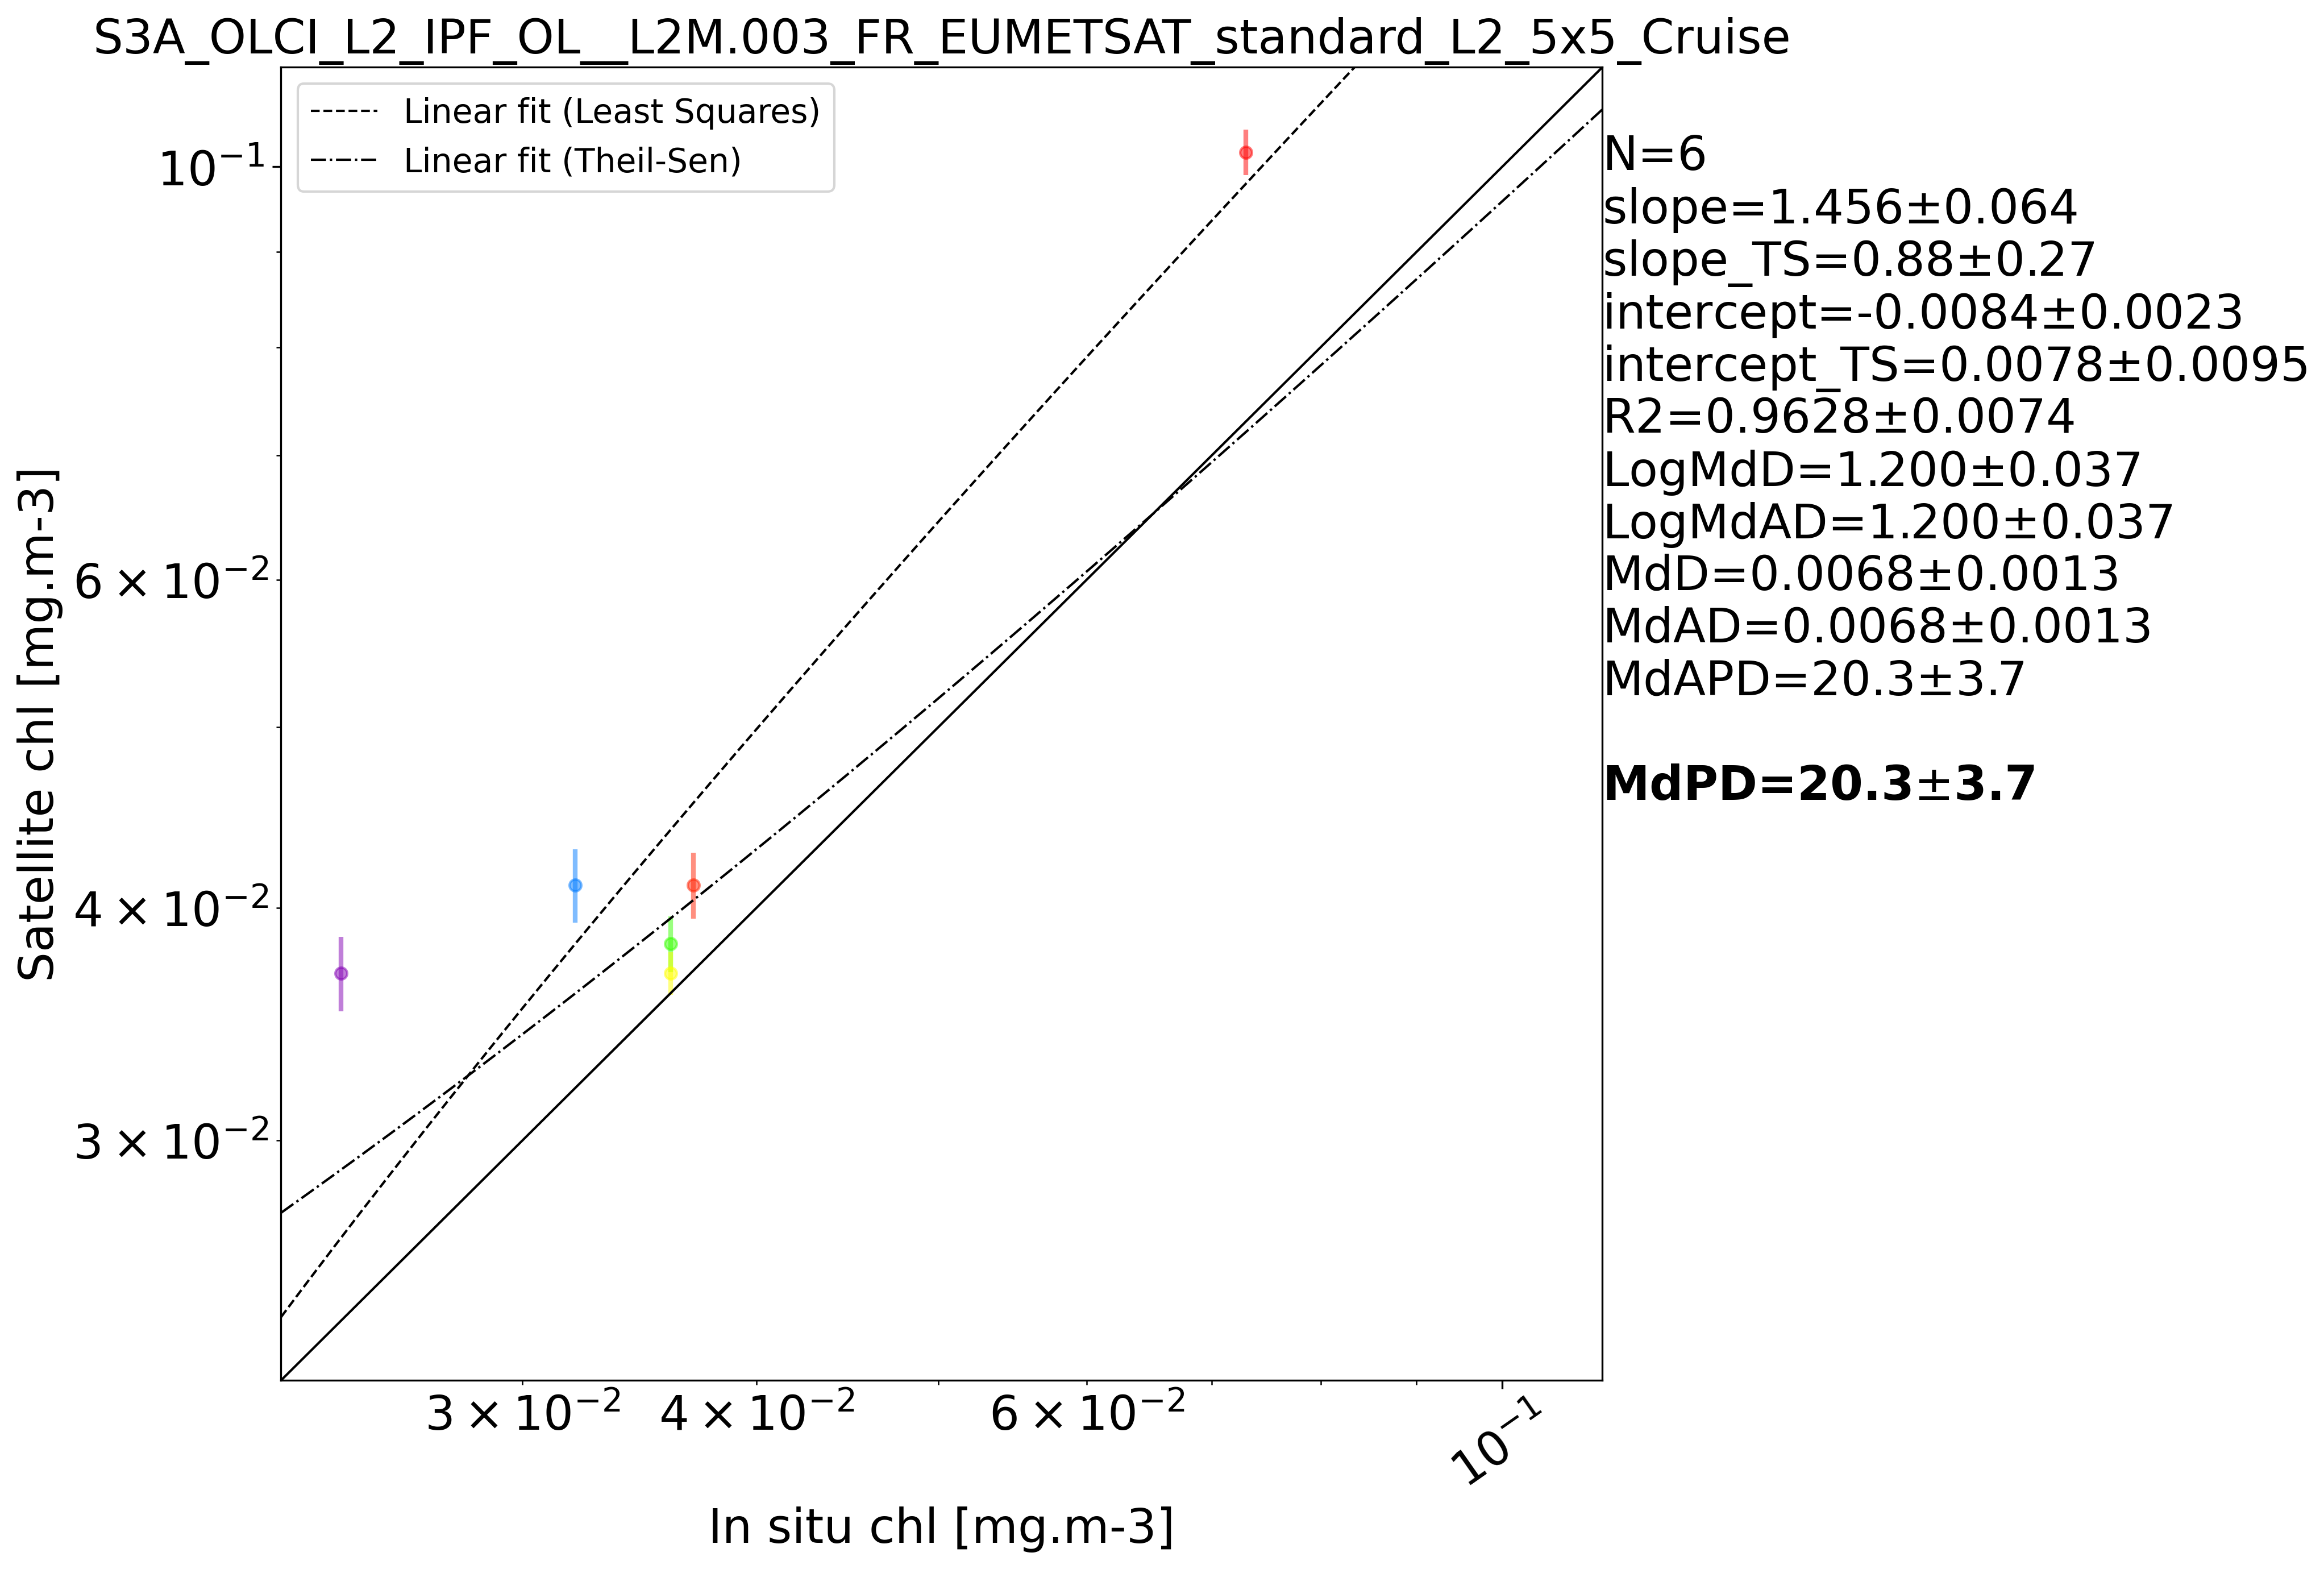

In [16]:
images = glob.glob(os.path.join(output_path, "MDB", "plots_global", "*.png"))
for image in sorted(images):
    display(Image(image))

Here we can see a full statistical comparison between the in situ and satellite chlorophyll measurements.

Finally, lets take a look at our match up analysis as a time series. For this, we need to work with the in situ database (IDB) and match-up database (MDB) files that ThoMaS creates. Lets read those in;

In [17]:
MDB_file = glob.glob(os.path.join(output_path, "MDB", "*.nc"))[0]
IDB_file = glob.glob(os.path.join(output_path, "IDB", "*.nc"))[0]
ds_MDB = xr.open_dataset(MDB_file)
ds_IDB = xr.open_dataset(IDB_file)

We need to do a little bit of cross referencing between the two file to find the correct indices of the match-up points so that we can collocate times. Additionally we need to format the dates to help with plotting.

In [18]:
# select indices
mask = np.isin(ds_MDB["matchup_id_all"], ds_MDB["matchup_id"])
indices = np.where(mask)[0]

# format dates
dt = ds_IDB["acquisition_time"].astype('datetime64[m]')

We are now ready to make our final plot.

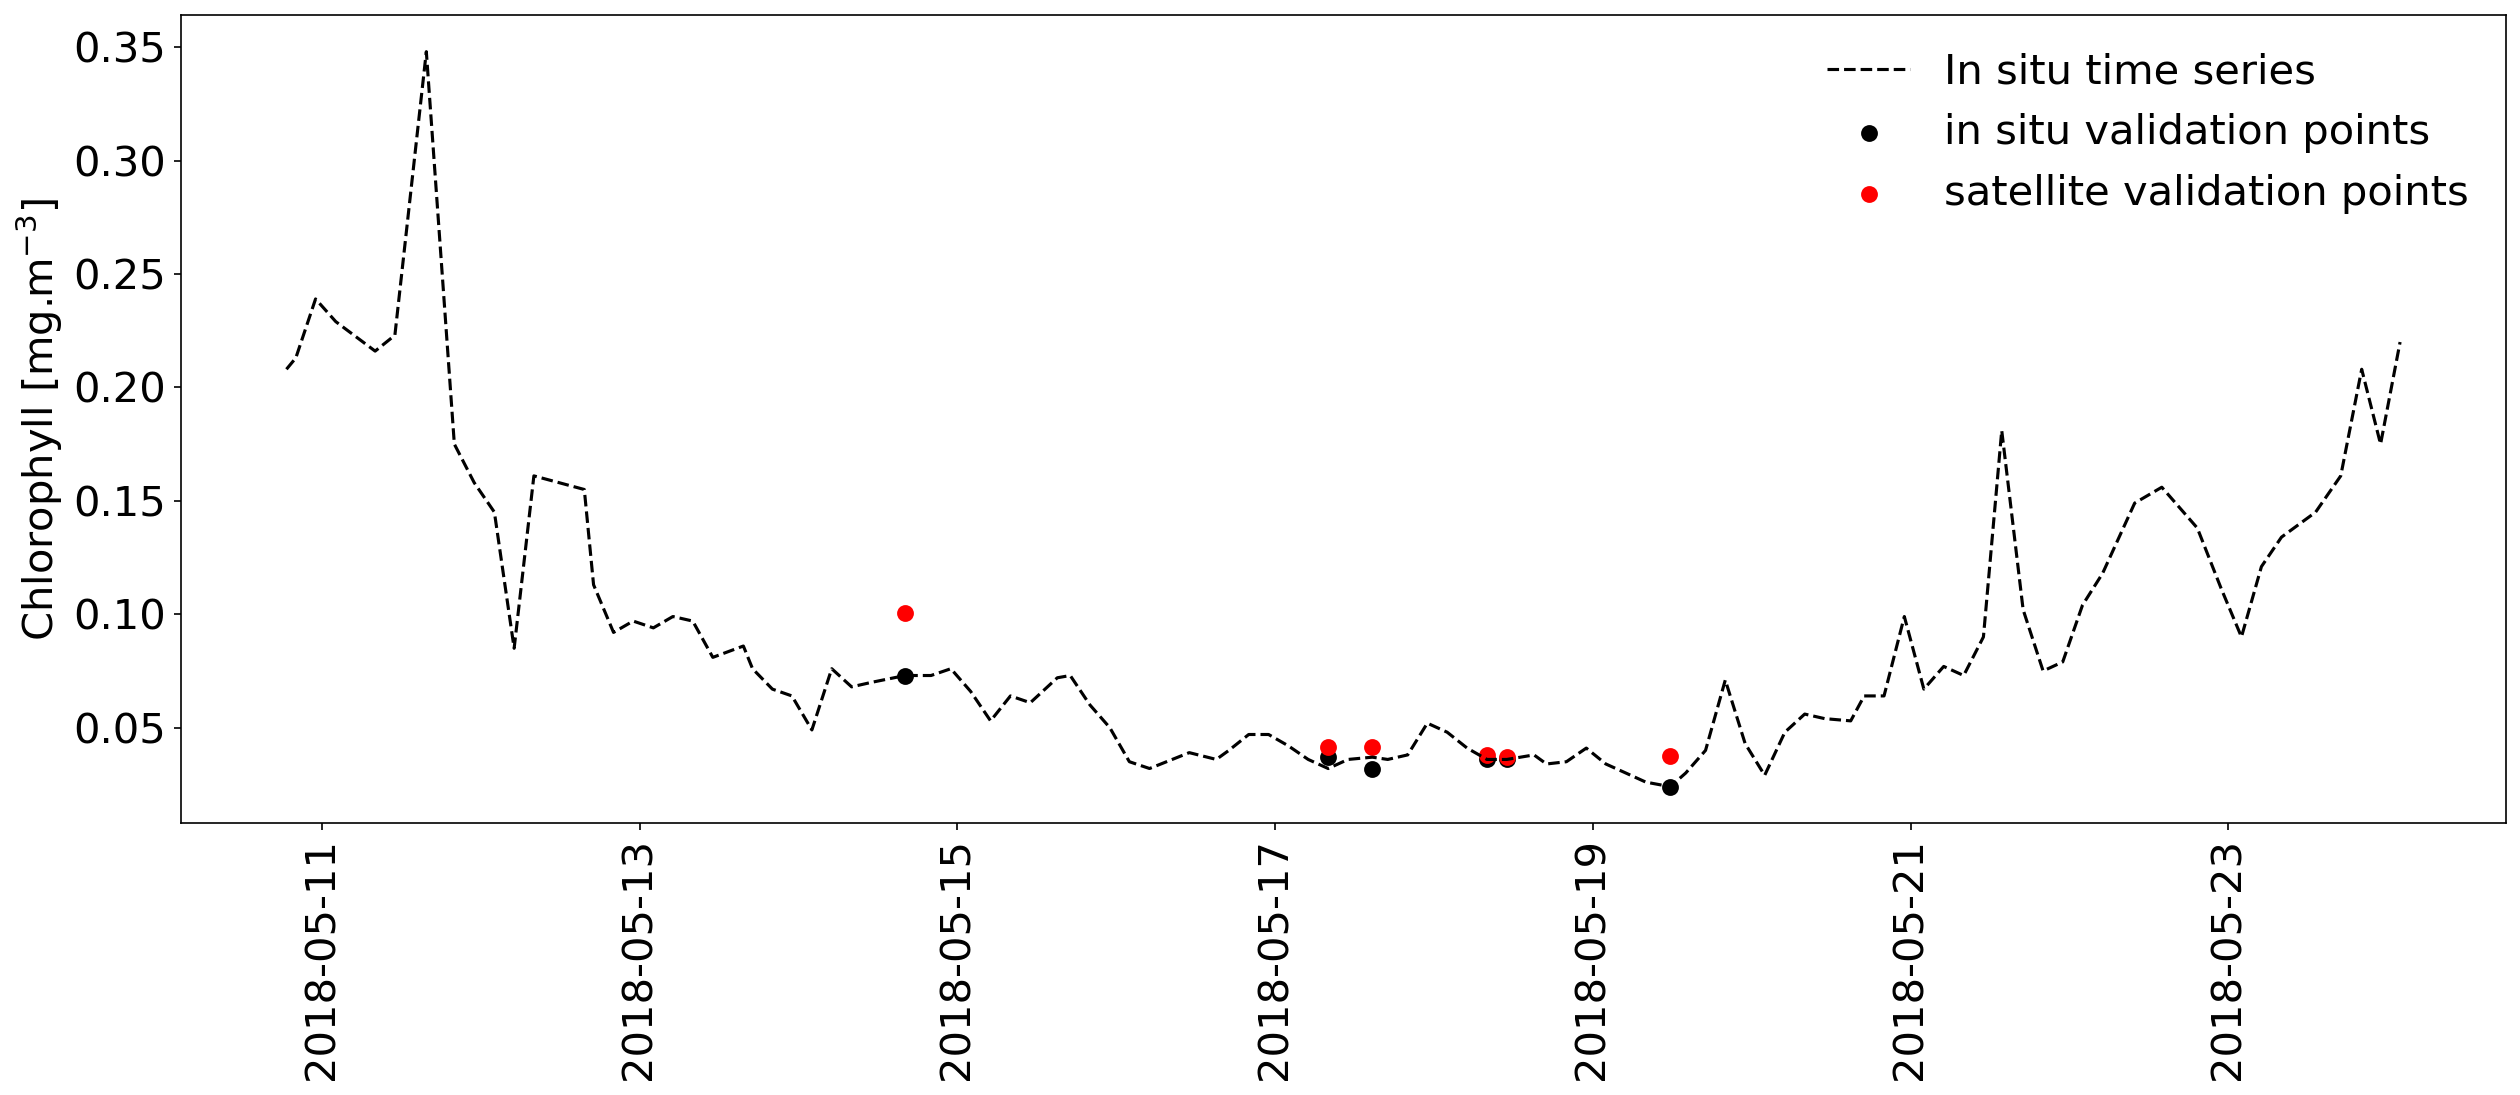

In [19]:
fig, m = plt.subplots(1, 1, figsize=(20, 7), dpi=150)
p1,= plt.plot(dt, ds_IDB["chl"], "k--")
p2 = plt.scatter(ds_MDB["insitu_acquisition_time"][indices], ds_MDB["insitu_chl"], s=50, c="k")
p3 = plt.scatter(ds_MDB["insitu_acquisition_time"][indices], ds_MDB["satellite_chl_mean"], s=50, c="r")
plt.xticks(rotation=90)
plt.ylabel("Chlorophyll [mg.m$^{-3}$]", fontsize=20)
plt.legend([p1, p2, p3], ["In situ time series", "in situ validation points" ,"satellite validation points"], fontsize=20, frameon=False);

<div class="alert alert-info" role="alert">

## <a id='section6'></a>What next?
[Back to top](#TOC-TOP)

</div>

Here, we have run ThoMaS to look at only chlorophyll-a, and only using OLCI. However, the package is designed to support full radiometric match-up validation routines for both hyperspectral and multispectral data sources, applying the necessary BRDF corrections as required. e.g. ThoMaS also supports both NASA MODIS and NASA PACE products.

You can find many more example of configuration files in the ./ThoMaS/examples directory. Building on these, and the examples shown above you should be able to build a validation workflow that works for your circumstances, including to extract matchups for the current ESA OTC cruise! Get in touch if you'd like to work with us on this!

If you have any questions about this notebook, the use/development of the ThoMaS package - please contact the <a href=mailto:ops@eumetsat.int target="_blank">EUMETSAT helpdesk</a>. 

If this has peaked your interest - we will also have several trainings relating to ThoMaS, HyperCP (another package developed under the <a href="https://frm4soc2.eumetsat.int/" target="_blank">FRM4SOC-2 project</a>) and an advanced Ocean Colour training at EUMETSAT, associated with the upcoming IOCS conference in December 2025. Check out the <a href="https://iocs.ioccg.org/" target="_blank">IOCS conference website</a> and the <a href="https://trainingevents.eumetsat.int/ " target="_blank">EUMETSAT training calendar</a> for announcements shortly.

<hr>
<a href="../../Index.ipynb" target="_blank"><< Index</a>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean" target="_blank">View on GitLab</a> | <a href="https://training.eumetsat.int/" target="_blank">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int target="_blank">Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int target="_blank">Contact our training team to collaborate on and reuse this material</a></span></p>